# pred-3-extra, part 2: naming the author from a learned encoder

pred-3 named the author of a single message from word and character n-grams, a
stylistic fingerprint built by hand, and reached about 68 percent out of 110 people.
This part swaps that fingerprint for a pretrained encoder's own representation, the
pooled hidden layer of a small transformer, and asks whether a learned vector of the
text does better, worse, or simply different.

The setup is the pred-3 authorship setup unchanged: the same 110 authors, the same
up-to-600 messages each, the same thread-grouped split that keeps a test message from
sharing a conversation with a training one. The words baseline is loaded from the
pred-3 cache, so the only thing that moves is the content representation. The encoder
is MiniLM, run through fastembed, which is ONNX-based and needs no GPU.

In [1]:
# Experiment 2: name the author from a pretrained encoder's embedding, against the pred-3 word model.
# Reuses the pred-3 authorship message set, thread-grouped split, and cached TF-IDF baseline.
from pathlib import Path
import re, collections, pickle, numpy as np, pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import plotly.graph_objects as go
import plotly.io as pio
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MTAG = MODEL.split("/")[-1]

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found")
ROOT = find_root()
CLEAN, REFS = ROOT / "eda-5" / "clean", ROOT / "eda-5" / "refs"
PLOTS = ROOT / "pred-3-extra" / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)
WORKDIR = ROOT / "pred-3-extra" / "work"; WORKDIR.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE, LBLUE, TEAL = "#6a3d9a", "#8db4d8", "#2a9d8f"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"
def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3); _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out))); return fig

## The message set and the words baseline

This rebuilds the exact pred-3 authorship frame and split, then loads the cached
TF-IDF word scores as the baseline to beat. `Sc` is the words decision-score matrix on
the held-out messages, and `classes` is the author order the scores are indexed by.

In [2]:
# ===== rebuild the pred-3 authorship set (cell 3, verbatim through the split) =====
m = pd.read_parquet(CLEAN / "messages_clean.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet", columns=["message_id", "recipient_person"])
DEL = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])
au_all = m[m.sender_person.notna() & ~m.from_addr_norm.isin(DEL)
          & ~m.body_is_boilerplate & ~m.body_empty_after_clean & m.body.notna()].copy()
cnt = au_all.groupby("sender_person").size()
authors = sorted(cnt[cnt >= 120].index)
CAP = 600
idx = []
for a, gdf in au_all[au_all.sender_person.isin(authors)].groupby("sender_person"):
    idx.extend(gdf.sample(n=min(CAP, len(gdf)), random_state=0).index)
au = au_all.loc[idx].reset_index(drop=True)
au["hour"] = au["date"].dt.hour.where(au["date_plausible"]).fillna(12)
au["dow"] = au["date"].dt.dayofweek.where(au["date_plausible"]).fillna(2)
au["weekend"] = (au["dow"] >= 5).astype(int)
au["subj_len"] = au["subject"].fillna("").str.len()
au["is_reply"] = (au["thread_position"] > 0).astype(int)
ENV = ["to_count", "cc_count", "recipient_count", "external_recipient_count", "has_external_recipient",
       "list_recipient_count", "has_list_recipient", "file_size", "body_chars", "body_was_trimmed",
       "is_thread_root", "thread_position", "thread_size", "in_sent", "hour", "dow", "weekend",
       "subj_len", "is_reply"]
Xenv = au[ENV].astype(float).fillna(0.0).values
for c in ["file_size", "body_chars", "thread_size", "subj_len"]:
    Xenv[:, ENV.index(c)] = np.log1p(Xenv[:, ENV.index(c)])
y = au["sender_person"].values
groups = au["thread_id"].values
NAME = roles.set_index("owner")["display_name"].to_dict()
body = au["body"].values
tr, te = next(StratifiedGroupKFold(5, shuffle=True, random_state=0).split(au, y, groups))
yte = y[te]
print(f"{len(au)} messages, {len(authors)} authors, chance {1/len(authors):.3f}; train {len(tr)} test {len(te)}")

WORD = dict(lowercase=True, strip_accents="unicode", token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
            ngram_range=(1, 2), min_df=3, max_features=15000, sublinear_tf=True)
CHAR = dict(lowercase=True, strip_accents="unicode", analyzer="char_wb",
            ngram_range=(3, 4), min_df=5, max_features=20000, sublinear_tf=True)
def text_scores(text):
    w, c = TfidfVectorizer(**WORD), TfidfVectorizer(**CHAR)
    Xtr = sparse.hstack([w.fit_transform(text[tr]), c.fit_transform(text[tr])]).tocsr()
    Xte = sparse.hstack([w.transform(text[te]), c.transform(text[te])]).tocsr()
    clf = LinearSVC(C=1.0, dual=True, max_iter=2000).fit(Xtr, y[tr])
    return clf.decision_function(Xte), clf.classes_

# TF-IDF word baseline: load pred-3's cached scores if the split matches, else compute
sig = str((CAP, len(au), len(tr), WORD, CHAR))
p3cache = ROOT / "pred-3" / "work" / "auth_scores.pkl"
blob = pickle.load(open(p3cache, "rb")) if p3cache.exists() else None
if blob and blob["sig"] == sig:
    Sc, Sn, Sm, classes, meta_coef = blob["data"]; print("loaded pred-3 TF-IDF baseline from cache")
else:
    Sc, classes = text_scores(body); print("recomputed TF-IDF baseline")

48063 messages, 110 authors, chance 0.009; train 38451 test 9612
loaded pred-3 TF-IDF baseline from cache


## Embedding each message, and reading the author off it

Each message body becomes one 384-dimensional MiniLM vector, cached to disk so a
re-run skips the encoding. A linear classifier reads the author from those vectors,
and the words and the encoder are late-fused by blending their decision margins,
exactly as pred-3 blended the words with the envelope.

In [3]:
# ===== encoder embeddings, cached =====
embfile = WORKDIR / f"emb_{MTAG}.npy"
if embfile.exists():
    emb = np.load(embfile); print(f"loaded cached embeddings {emb.shape}")
else:
    from fastembed import TextEmbedding
    import time
    t0 = time.time()
    enc = TextEmbedding(model_name=MODEL)
    emb = np.array(list(enc.embed(list(body), batch_size=256))).astype(np.float32)
    np.save(embfile, emb)
    print(f"encoded {emb.shape} in {time.time()-t0:.0f}s with {MTAG}")

# classify the author from the embedding (dense, n_samples > n_features, so primal solver)
sc = StandardScaler().fit(emb[tr])
esvc = LinearSVC(C=1.0, dual=False, max_iter=3000).fit(sc.transform(emb[tr]), y[tr])
Se = esvc.decision_function(sc.transform(emb[te]))
assert list(esvc.classes_) == list(classes), "class order mismatch between embedding and TF-IDF"

def acc(S): p = classes[S.argmax(1)]; return accuracy_score(yte, p), balanced_accuracy_score(yte, p)
mi_e, ma_e = acc(Se)
mi_c, ma_c = acc(Sc)
# late fusion of the two content views, sweep the weight on the embedding
zc = (Sc - Sc.mean()) / Sc.std()
ze = (Se - Se.mean()) / Se.std()
ws = np.round(np.linspace(0, 2.0, 41), 3)
fus_mi = np.array([accuracy_score(yte, classes[(zc + w * ze).argmax(1)]) for w in ws])
fus_ma = np.array([balanced_accuracy_score(yte, classes[(zc + w * ze).argmax(1)]) for w in ws])
wbest = ws[int(fus_mi.argmax())]
mi_f, ma_f = fus_mi.max(), fus_ma[int(fus_mi.argmax())]
chance = 1 / len(classes)
print(f"embedding({MTAG}) micro {mi_e:.3f} macro {ma_e:.3f}")
print(f"words(TF-IDF)      micro {mi_c:.3f} macro {ma_c:.3f}")
print(f"fused best w={wbest} micro {mi_f:.3f} macro {ma_f:.3f}  gain over words {mi_f-mi_c:+.3f}")

loaded cached embeddings (48063, 384)


embedding(all-MiniLM-L6-v2) micro 0.357 macro 0.329
words(TF-IDF)      micro 0.675 macro 0.640
fused best w=0.25 micro 0.678 macro 0.641  gain over words +0.003


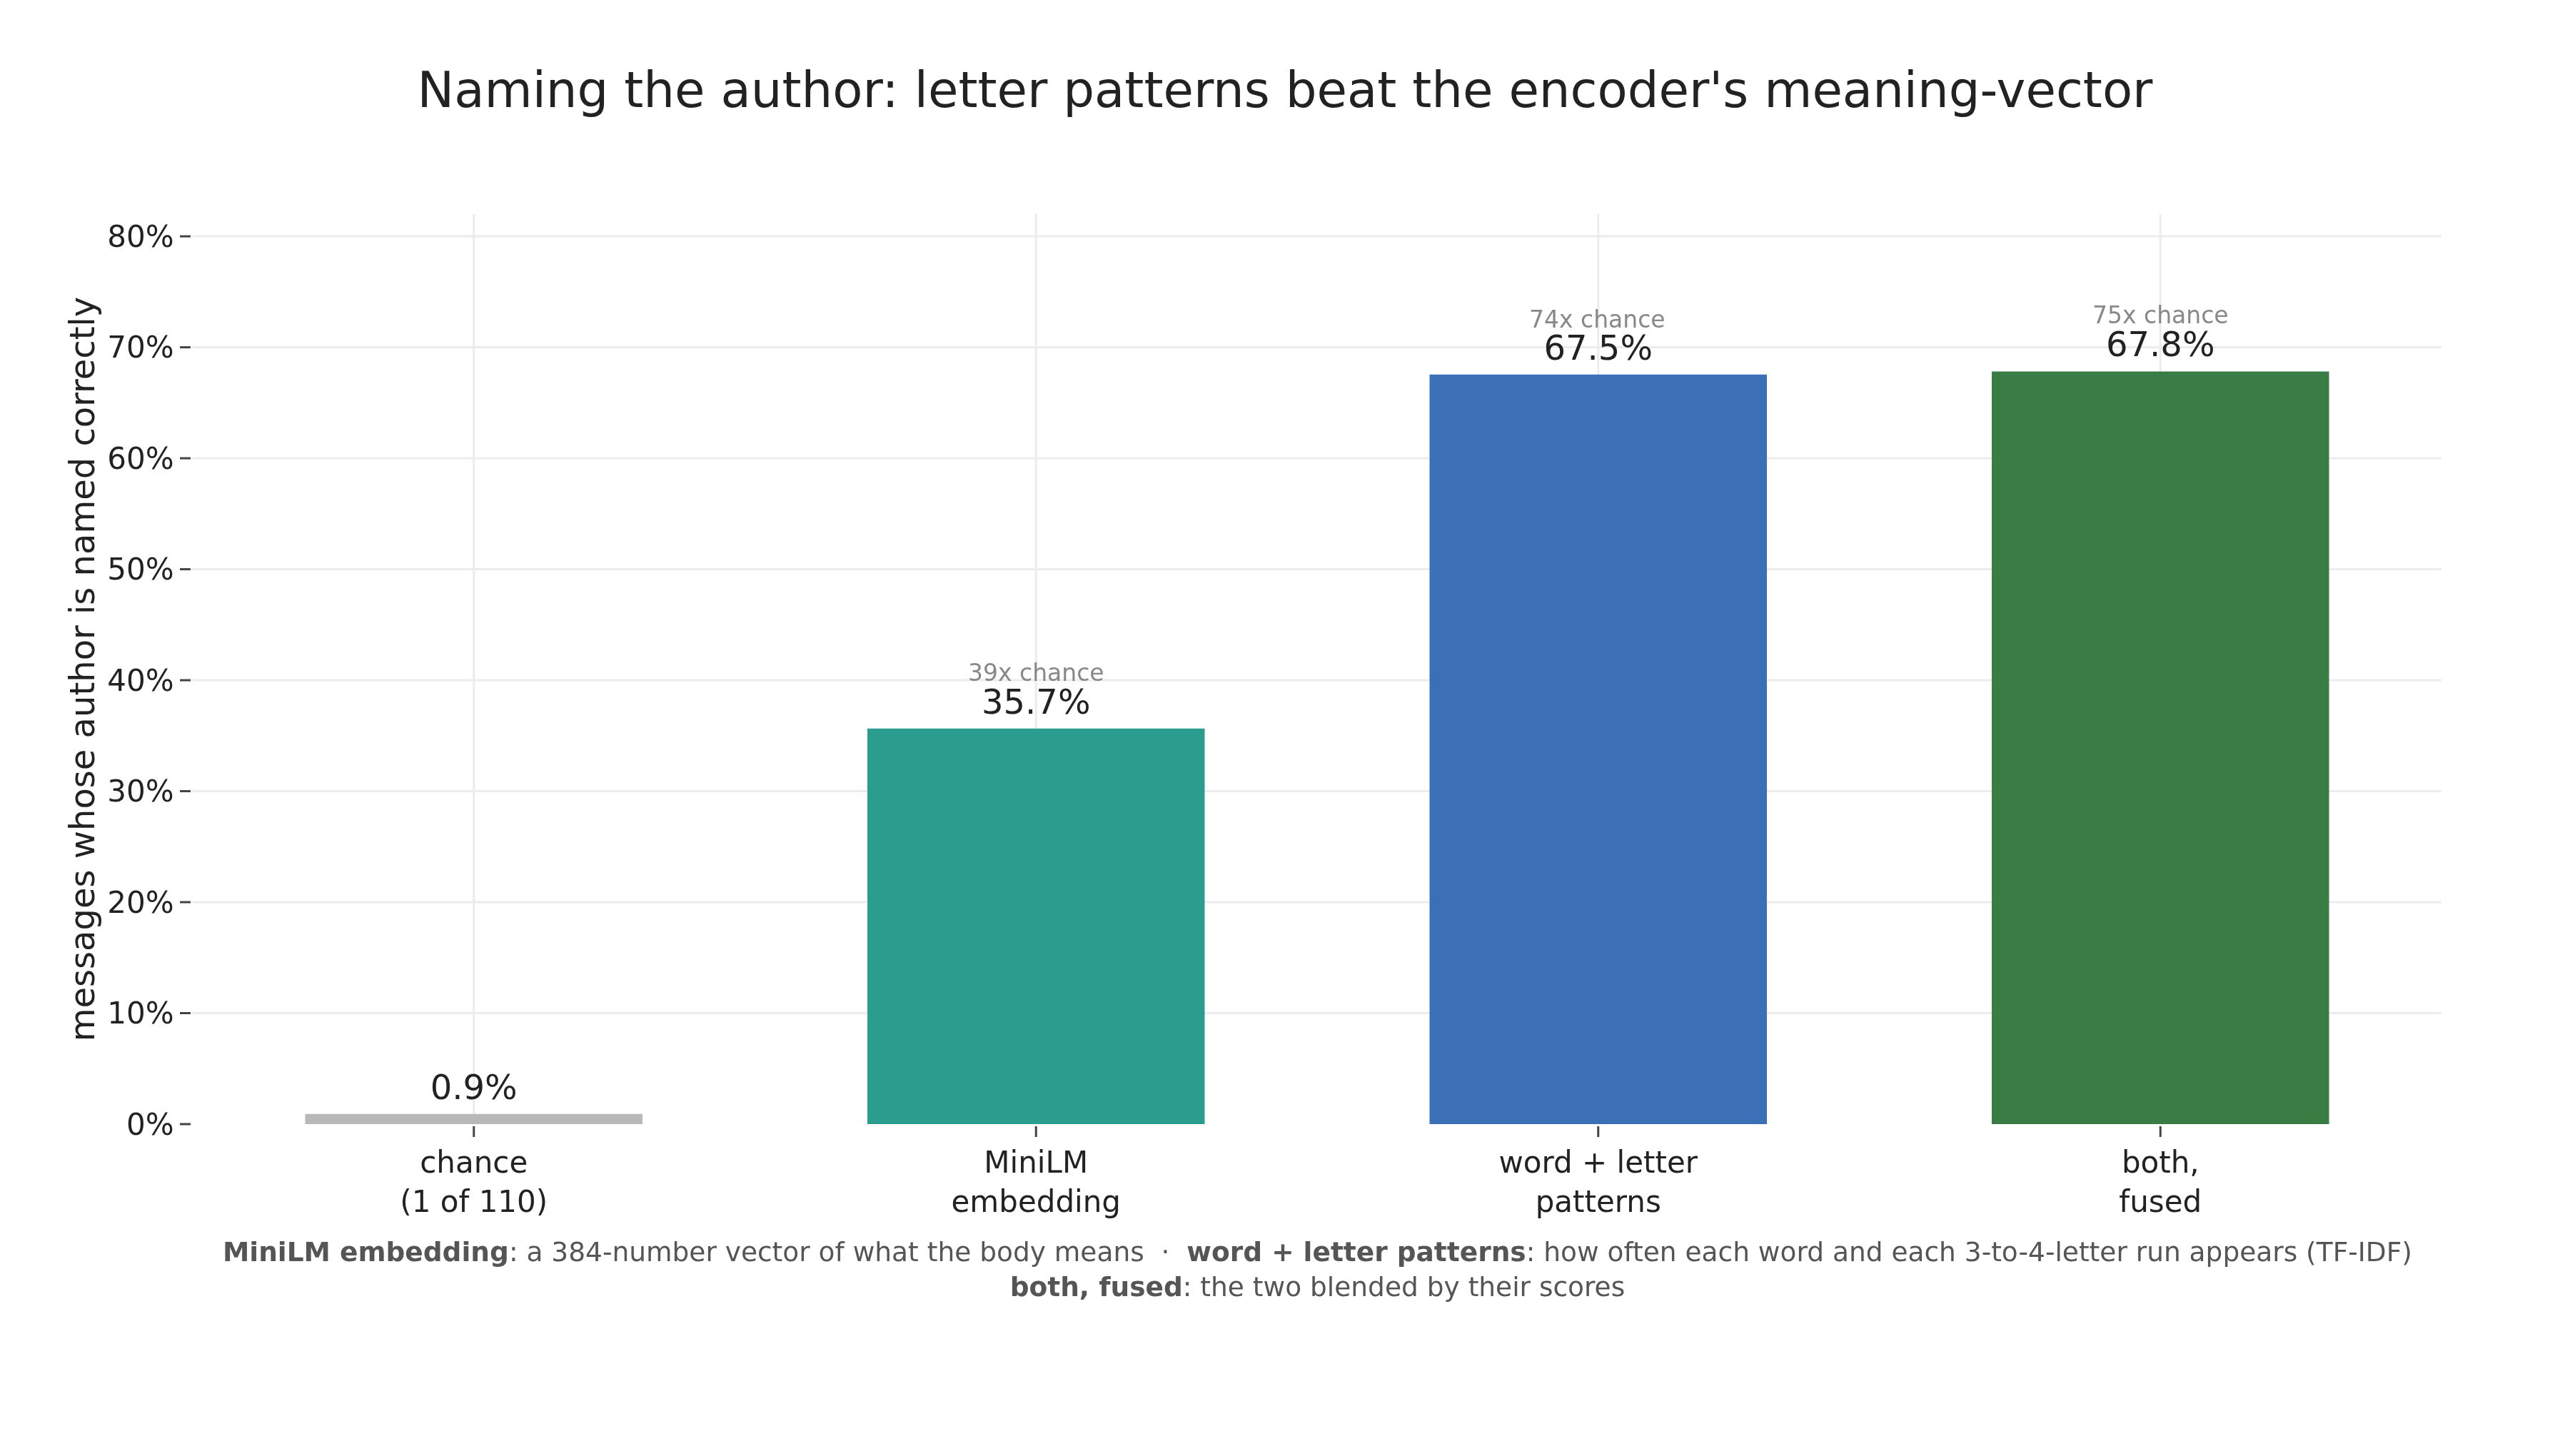

In [4]:
# ===== e1: accuracy bars =====
bars = [("chance<br>(1 of 110)", chance, GREY), ("MiniLM<br>embedding", mi_e, TEAL),
        ("word + letter<br>patterns", mi_c, BLUE), ("both,<br>fused", mi_f, GREEN)]
fig = go.Figure(go.Bar(x=[b[0] for b in bars], y=[b[1] * 100 for b in bars],
    marker_color=[b[2] for b in bars], width=0.6,
    text=[f"{b[1]*100:.1f}%" for b in bars], textposition="outside", textfont=dict(size=16),
    cliponaxis=False, showlegend=False))
for b in bars:
    if b[1] > chance * 2:
        fig.add_annotation(x=b[0], y=b[1] * 100 + 5.0, text=f"{b[1]/chance:.0f}x chance",
            showarrow=False, font=dict(size=11, color="#888"))
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=-0.20, xanchor="center", align="center", showarrow=False,
    text="<b>MiniLM embedding</b>: a 384-number vector of what the body means&nbsp;&nbsp;·&nbsp;&nbsp;"
         "<b>word + letter patterns</b>: how often each word and each 3-to-4-letter run appears (TF-IDF)<br>"
         "<b>both, fused</b>: the two blended by their scores", font=dict(size=12.5, color="#555"))
fig.update_yaxes(title_text="messages whose author is named correctly", range=[0, 82], ticksuffix="%")
fig.update_layout(title="Naming the author: letter patterns beat the encoder's meaning-vector")
save_fig(fig, "e1_encoder_vs_words.png", w=1200, h=680, margin=dict(l=90, r=60, t=100, b=155))

The encoder names the author of about a third of the messages, 36 percent, which is
forty times chance but only half of what the hand-made words reach at 68 percent.
Fusing the two moves the result by three tenths of a point, which is nothing. A
general-purpose encoder is trained to place text by meaning, and it smooths over the
spelling, spacing, and punctuation that actually give a writer away. For identity, the
characters win.

cosine distance in encoder space: confused pairs 0.18 vs typical pair 0.22


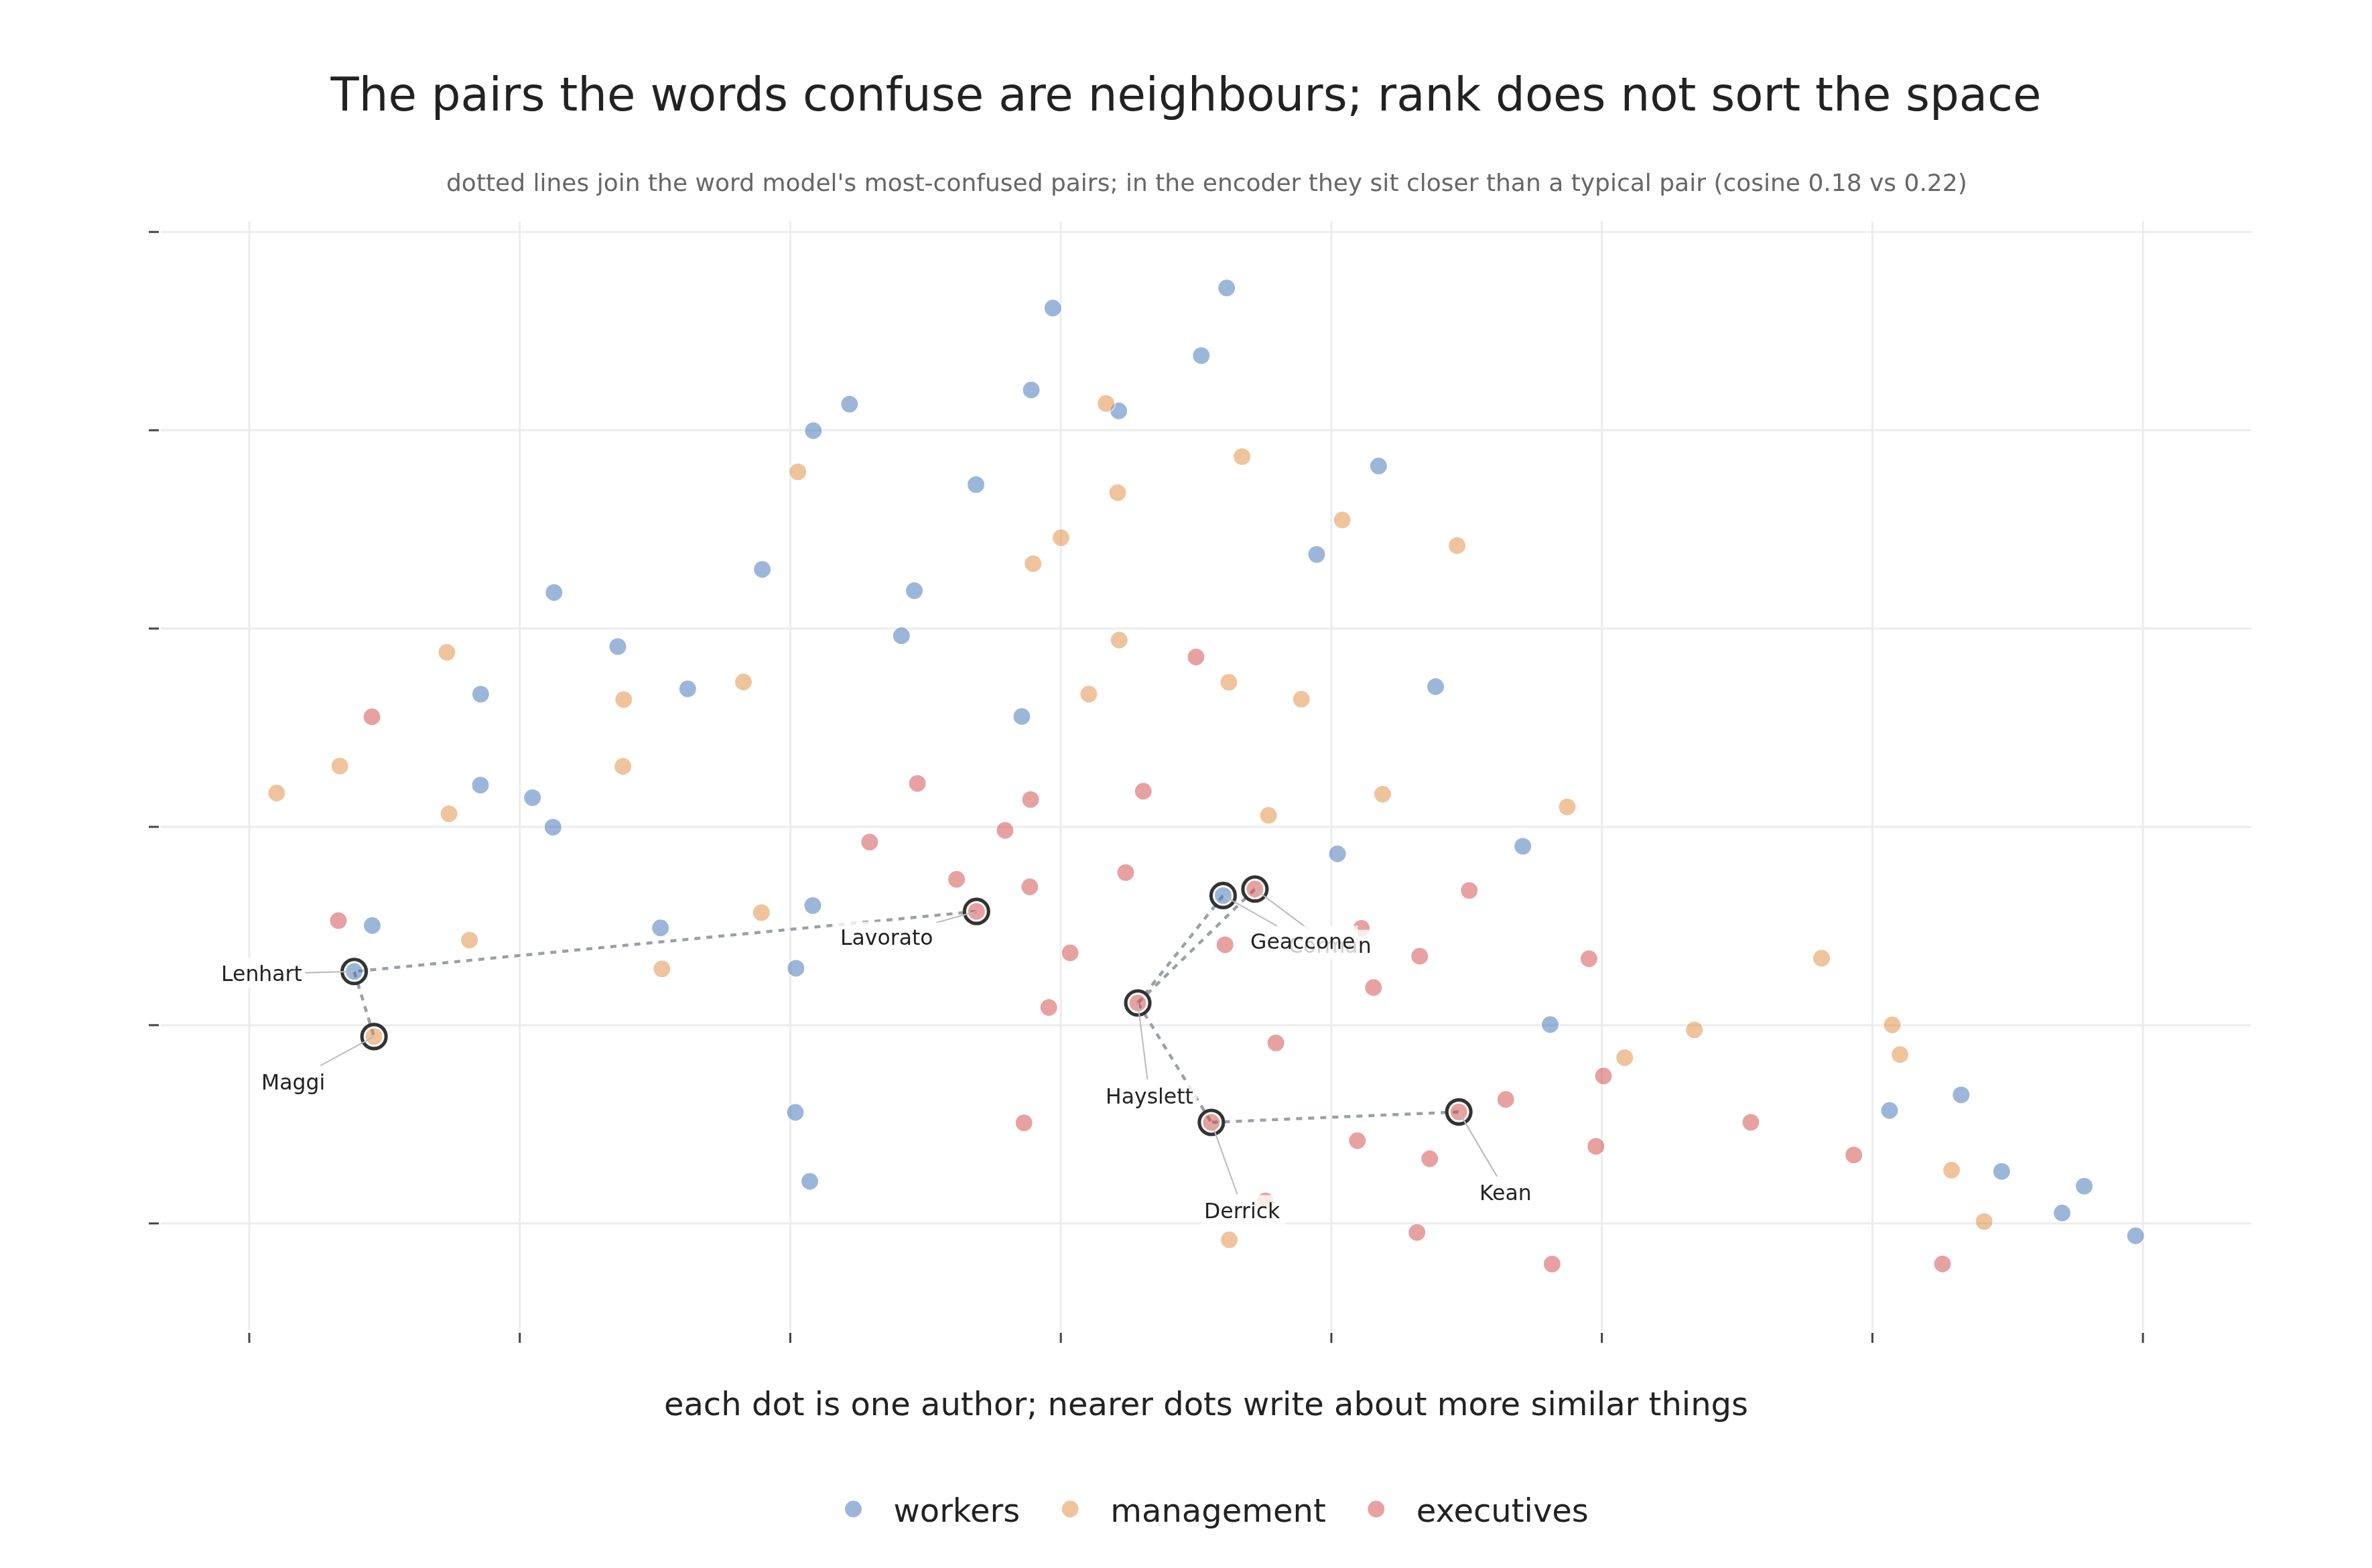

saved e1_encoder_vs_words.png, e2_author_space.png


In [5]:
# ===== e2: the 110 authors in encoder space =====
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances
au_mean = pd.DataFrame(emb).groupby(y).mean()          # one mean vector per author
order = list(au_mean.index)
V = normalize(au_mean.values)                          # unit vectors, cosine geometry
ai = {a: i for i, a in enumerate(order)}
Dfull = cosine_distances(V)                            # closeness measured in the full 384-d space
P = TSNE(n_components=2, perplexity=15, init="pca", random_state=0).fit_transform(V)  # 2-d layout only
pos = {a: P[i] for i, a in enumerate(order)}
# seniority tier per author (grouping X from Experiment 1)
TIER_X = {1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 7: 2}
rank = roles.set_index("owner")["seniority_rank"].to_dict()
tier = {a: TIER_X.get(int(rank[a]), None) if a in rank and pd.notna(rank[a]) else None for a in order}
TCOL = {0: BLUE, 1: ORANGE, 2: RED, None: GREY}
TNAME = {0: "workers", 1: "management", 2: "executives", None: "unranked"}
# which author pairs the word model confuses, and are they neighbours here?
predc = classes[Sc.argmax(1)]
miss = collections.Counter((yte[i], predc[i]) for i in np.where(predc != yte)[0])
conf_pairs = [(a, b, n) for (a, b), n in miss.most_common(8) if a in ai and b in ai]
conf_d = float(np.mean([Dfull[ai[a], ai[b]] for a, b, _ in conf_pairs]))
all_d = float(Dfull[np.triu_indices(len(order), 1)].mean())
print(f"cosine distance in encoder space: confused pairs {conf_d:.2f} vs typical pair {all_d:.2f}")

fig = go.Figure()
# confused-pair links first, so the points sit on top of them
for a, b, n in conf_pairs[:6]:
    fig.add_trace(go.Scatter(x=[pos[a][0], pos[b][0]], y=[pos[a][1], pos[b][1]], mode="lines",
        line=dict(color="#9aa0a6", width=1.5, dash="dot"), hoverinfo="skip", showlegend=False))
# the 110 authors, coloured by tier but held back so the links and pairs read
for t in [0, 1, 2, None]:
    pts = [a for a in order if tier[a] == t]
    if not pts: continue
    fig.add_trace(go.Scatter(x=[pos[a][0] for a in pts], y=[pos[a][1] for a in pts], mode="markers",
        name=TNAME[t], marker=dict(size=9, color=TCOL[t], opacity=0.5, line=dict(color="white", width=0.7))))
# ring and label only the confused endpoints
endpts = list({a for a, b, _ in conf_pairs[:6]} | {b for a, b, _ in conf_pairs[:6]})
fig.add_trace(go.Scatter(x=[pos[a][0] for a in endpts], y=[pos[a][1] for a in endpts], mode="markers",
    marker=dict(size=12, color="rgba(0,0,0,0)", line=dict(color="#333", width=1.7)),
    hoverinfo="skip", showlegend=False))
for i, a in enumerate(sorted(endpts, key=lambda z: (round(pos[z][0], 1), pos[z][1]))):
    ang = 2 * np.pi * i / len(endpts) - np.pi / 2   # a distinct compass direction per label
    fig.add_annotation(x=pos[a][0], y=pos[a][1], text=NAME.get(a, a).split()[-1],
        showarrow=True, arrowhead=0, arrowwidth=0.7, arrowcolor="#bcbcbc",
        ax=float(52 * np.cos(ang)), ay=float(-52 * np.sin(ang)), axref="pixel", ayref="pixel",
        font=dict(size=10.5, color="#222"), bgcolor="rgba(255,255,255,0.8)")
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=1.05, xanchor="center", showarrow=False,
    text=f"dotted lines join the word model's most-confused pairs; in the encoder they sit closer "
         f"than a typical pair (cosine {conf_d:.2f} vs {all_d:.2f})", font=dict(size=12, color="#666"))
fig.update_xaxes(title_text="each dot is one author; nearer dots write about more similar things", showticklabels=False)
fig.update_yaxes(title_text="", showticklabels=False)
fig.update_layout(title="The pairs the words confuse are neighbours; rank does not sort the space",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.13, yanchor="top"))
save_fig(fig, "e2_author_space.png", w=1180, h=780, margin=dict(l=80, r=60, t=110, b=110))
print("saved e1_encoder_vs_words.png, e2_author_space.png")

The encoder is not blind, it is reading something real, just not identity. Averaged
to one point per author, the space does not sort people by rank: the three tiers are
mixed all through it. What it captures is subject. The pairs the word model most often
confuses sit closer in the encoder than a typical pair does, a cosine 0.18 against 0.22. People who work
the same desk write about the same things, land in the same region of encoder space,
and are the ones mistaken for each other. Meaning and style are two different signals,
and naming a person needs the style.